In [2]:
import os
print(os.path.abspath("KNN.ipynb"))

C:\Users\JEAN\KNN.ipynb


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [13]:
data=pd.read_csv('C:/Users/JEAN/OneDrive/Dokumente/project_data/data.csv')
print(data.head)

<bound method NDFrame.head of            id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0      842302         M        17.99         10.38          122.80     1001.0   
1      842517         M        20.57         17.77          132.90     1326.0   
2    84300903         M        19.69         21.25          130.00     1203.0   
3    84348301         M        11.42         20.38           77.58      386.1   
4    84358402         M        20.29         14.34          135.10     1297.0   
..        ...       ...          ...           ...             ...        ...   
564    926424         M        21.56         22.39          142.00     1479.0   
565    926682         M        20.13         28.25          131.20     1261.0   
566    926954         M        16.60         28.08          108.30      858.1   
567    927241         M        20.60         29.33          140.10     1265.0   
568     92751         B         7.76         24.54           47.92      181.0  

In [3]:
print(data.columns)

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')


In [15]:
data = data.drop(columns=['id', 'Unnamed: 32'], errors='ignore')

print(f"Dataset shape: {data.shape}")
data.head()

Dataset shape: (569, 31)


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


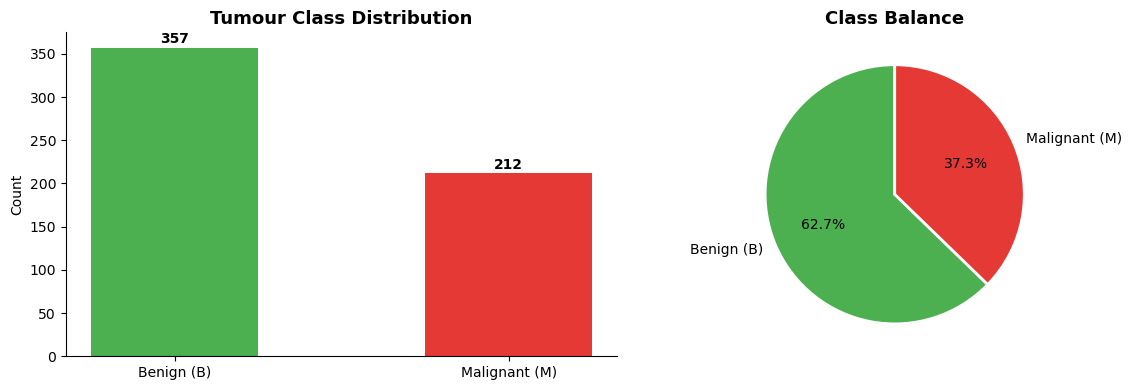

Benign:    357 (62.7%)
Malignant: 212 (37.3%)


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
count,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,...,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00,569.00
mean,14.13,19.29,91.97,654.89,0.10,0.10,0.09,0.05,0.18,0.06,...,16.27,25.68,107.26,880.58,0.13,0.25,0.27,0.11,0.29,0.08
std,3.52,4.30,24.30,351.91,0.01,0.05,0.08,0.04,0.03,0.01,...,4.83,6.15,33.60,569.36,0.02,0.16,0.21,0.07,0.06,0.02
min,6.98,9.71,43.79,143.50,0.05,0.02,0.00,0.00,0.11,0.05,...,7.93,12.02,50.41,185.20,0.07,0.03,0.00,0.00,0.16,0.06
25%,11.70,16.17,75.17,420.30,0.09,0.06,0.03,0.02,0.16,0.06,...,13.01,21.08,84.11,515.30,0.12,0.15,0.11,0.06,0.25,0.07
50%,13.37,18.84,86.24,551.10,0.10,0.09,0.06,0.03,0.18,0.06,...,14.97,25.41,97.66,686.50,0.13,0.21,0.23,0.10,0.28,0.08
75%,15.78,21.80,104.10,782.70,0.11,0.13,0.13,0.07,0.20,0.07,...,18.79,29.72,125.40,1084.00,0.15,0.34,0.38,0.16,0.32,0.09
max,28.11,39.28,188.50,2501.00,0.16,0.35,0.43,0.20,0.30,0.10,...,36.04,49.54,251.20,4254.00,0.22,1.06,1.25,0.29,0.66,0.21


In [18]:
# Class distribution 
counts = data['diagnosis'].value_counts()
colors = ['#4CAF50', '#E53935']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['Benign (B)', 'Malignant (M)'], counts.values, color=colors, width=0.5)
axes[0].set_title('Tumour Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=['Benign (B)', 'Malignant (M)'],
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Balance', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Benign:    {counts['B']} ({counts['B']/len(data)*100:.1f}%)")
print(f"Malignant: {counts['M']} ({counts['M']/len(data)*100:.1f}%)")
data.describe().round(2)

In [19]:
# --- Encode the target label ---
# M (Malignant) → 1  |  B (Benign) → 0
data['label'] = data['diagnosis'].map({'M': 1, 'B': 0})

# Separate features and labels
X = data.drop(columns=['diagnosis', 'label']).values.astype(float)
y = data['label'].values

# --- Min-Max Normalisation (written from scratch) ---
def min_max_normalise(X):
    """Scale each feature to [0, 1] range."""
    X_min = X.min(axis=0)
    X_max = X.max(axis=0)
    return (X - X_min) / (X_max - X_min + 1e-8)  # +1e-8 to avoid division by zero

X_scaled = min_max_normalise(X)

# Sanity check: all values should now be between 0 and 1
print(f"Feature matrix shape : {X_scaled.shape}")
print(f"Min value after scaling: {X_scaled.min():.4f}")
print(f"Max value after scaling: {X_scaled.max():.4f}")

Feature matrix shape : (569, 30)
Min value after scaling: 0.0000
Max value after scaling: 1.0000


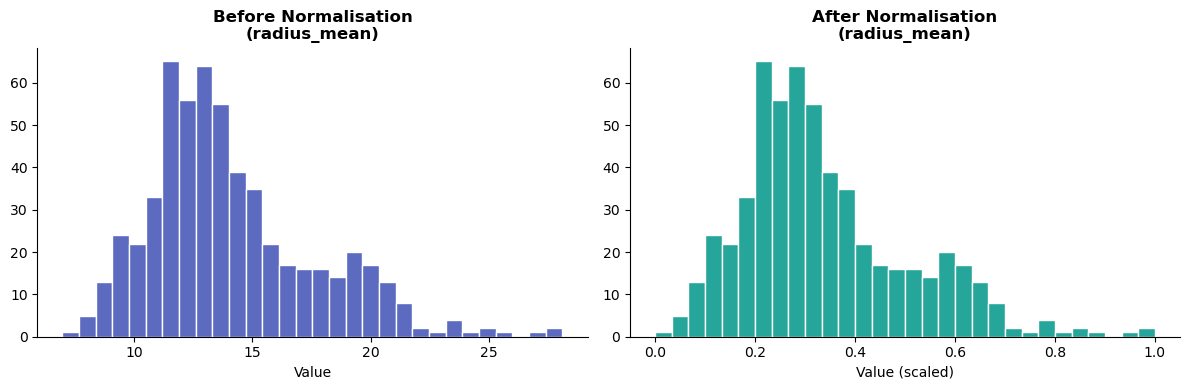

In [21]:
# Visualise the effect of normalisation on one feature
feature_idx = 0  # radius_mean
feature_name = data.drop(columns=['diagnosis', 'label']).columns[feature_idx]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X[:, feature_idx], bins=30, color='#5C6BC0', edgecolor='white')
axes[0].set_title(f'Before Normalisation\n({feature_name})', fontweight='bold')
axes[0].set_xlabel('Value')

axes[1].hist(X_scaled[:, feature_idx], bins=30, color='#26A69A', edgecolor='white')
axes[1].set_title(f'After Normalisation\n({feature_name})', fontweight='bold')
axes[1].set_xlabel('Value (scaled)')

plt.tight_layout()
plt.show()

In [22]:
def train_test_split(X, y, test_size=0.2, random_seed=42):
    """Randomly split data into training and test sets."""
    np.random.seed(random_seed)
    n_samples = len(X)
    n_test    = int(n_samples * test_size)

    # Shuffle indices
    indices = np.random.permutation(n_samples)

    test_idx  = indices[:n_test]
    train_idx = indices[n_test:]

    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)

print(f"Training samples : {len(X_train)}")
print(f"Test samples     : {len(X_test)}")
print(f"Train class balance — Benign: {sum(y_train==0)}, Malignant: {sum(y_train==1)}")
print(f"Test  class balance — Benign: {sum(y_test==0)}, Malignant: {sum(y_test==1)}")

Training samples : 456
Test samples     : 113
Train class balance — Benign: 286, Malignant: 170
Test  class balance — Benign: 71, Malignant: 42


In [23]:
def euclidean_distance(point_a, point_b):
    """Calculate straight-line distance between two points in n-dimensional space."""
    return np.sqrt(np.sum((point_a - point_b) ** 2))


def knn_predict_one(X_train, y_train, query_point, k):
    """
    Predict the class for a single query point.
    
    Steps:
      1. Compute distance to every training point
      2. Sort and grab the K nearest
      3. Majority vote
    """
    distances = [euclidean_distance(query_point, train_point)
                 for train_point in X_train]

    # Get indices of K smallest distances
    k_nearest_indices = np.argsort(distances)[:k]

    # Labels of those neighbours
    k_nearest_labels = y_train[k_nearest_indices]

    # Majority vote — most common label wins
    most_common = Counter(k_nearest_labels).most_common(1)
    return most_common[0][0]


def knn_predict(X_train, y_train, X_test, k):
    """Run predictions for all test points."""
    return np.array([knn_predict_one(X_train, y_train, point, k)
                     for point in X_test])


print("KNN functions defined.")
print("\nQuick sanity check — predicting first test point with k=5:")
pred = knn_predict_one(X_train, y_train, X_test[0], k=5)
label_map = {1: 'Malignant', 0: 'Benign'}
print(f"  Predicted : {label_map[pred]}")
print(f"  Actual    : {label_map[y_test[0]]}")

KNN functions defined.

Quick sanity check — predicting first test point with k=5:
  Predicted : Benign
  Actual    : Benign


In [24]:
def compute_metrics(y_true, y_pred):
    """Compute accuracy, precision, recall, and F1 score."""
    TP = np.sum((y_pred == 1) & (y_true == 1))  # Correctly predicted Malignant
    TN = np.sum((y_pred == 0) & (y_true == 0))  # Correctly predicted Benign
    FP = np.sum((y_pred == 1) & (y_true == 0))  # Predicted Malignant, was Benign
    FN = np.sum((y_pred == 0) & (y_true == 1))  # Predicted Benign, was Malignant

    accuracy  = (TP + TN) / len(y_true)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    return {'Accuracy': accuracy, 'Precision': precision,
            'Recall': recall, 'F1 Score': f1,
            'TP': TP, 'TN': TN, 'FP': FP, 'FN': FN}


def plot_confusion_matrix(metrics, title='Confusion Matrix'):
    """Plot a nicely formatted confusion matrix."""
    cm = np.array([[metrics['TN'], metrics['FP']],
                   [metrics['FN'], metrics['TP']]])

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.colorbar(im, ax=ax)

    classes = ['Benign (0)', 'Malignant (1)']
    tick_marks = np.arange(len(classes))
    ax.set_xticks(tick_marks); ax.set_xticklabels(classes, fontsize=11)
    ax.set_yticks(tick_marks); ax.set_yticklabels(classes, fontsize=11)

    thresh = cm.max() / 2
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]),
                    ha='center', va='center', fontsize=16, fontweight='bold',
                    color='white' if cm[i, j] > thresh else 'black')

    ax.set_xlabel('Predicted Label', fontsize=12)
    ax.set_ylabel('True Label', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()


# --- Run predictions with k=5 ---
K = 5
print(f"Running KNN with k={K} on {len(X_test)} test samples...")
y_pred = knn_predict(X_train, y_train, X_test, k=K)
print("Done!")

Running KNN with k=5 on 113 test samples...
Done!


  KNN Results  (k = 5)
  Accuracy  : 0.9646  (96.46%)
  Precision : 0.9524
  Recall    : 0.9524
  F1 Score  : 0.9524


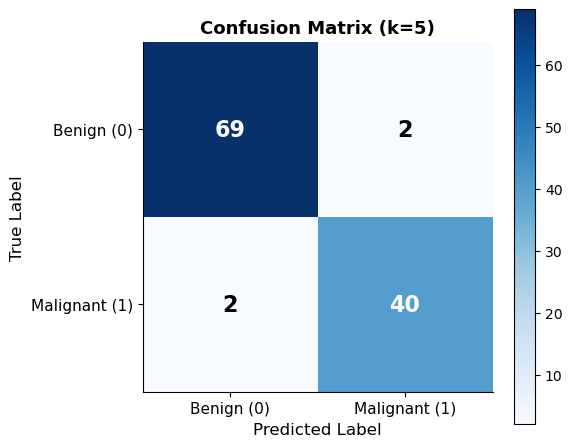

In [25]:
metrics = compute_metrics(y_test, y_pred)

print("=" * 40)
print(f"  KNN Results  (k = {K})")
print("=" * 40)
print(f"  Accuracy  : {metrics['Accuracy']:.4f}  ({metrics['Accuracy']*100:.2f}%)")
print(f"  Precision : {metrics['Precision']:.4f}")
print(f"  Recall    : {metrics['Recall']:.4f}")
print(f"  F1 Score  : {metrics['F1 Score']:.4f}")
print("=" * 40)

plot_confusion_matrix(metrics, title=f'Confusion Matrix (k={K})')

In [27]:
k_values   = list(range(1, 11))  # k from 1 to 30
accuracies = []
f1_scores  = []

for k in k_values:
    preds = knn_predict(X_train, y_train, X_test, k=k)
    m     = compute_metrics(y_test, preds)
    accuracies.append(m['Accuracy'])
    f1_scores.append(m['F1 Score'])
    print(f"k={k:2d}  |  Accuracy: {m['Accuracy']:.4f}  |  F1: {m['F1 Score']:.4f}")

k= 1  |  Accuracy: 0.9558  |  F1: 0.9412
k= 2  |  Accuracy: 0.9558  |  F1: 0.9412
k= 3  |  Accuracy: 0.9646  |  F1: 0.9524
k= 4  |  Accuracy: 0.9646  |  F1: 0.9524
k= 5  |  Accuracy: 0.9646  |  F1: 0.9524
k= 6  |  Accuracy: 0.9558  |  F1: 0.9412
k= 7  |  Accuracy: 0.9646  |  F1: 0.9524
k= 8  |  Accuracy: 0.9646  |  F1: 0.9524
k= 9  |  Accuracy: 0.9646  |  F1: 0.9524
k=10  |  Accuracy: 0.9646  |  F1: 0.9524


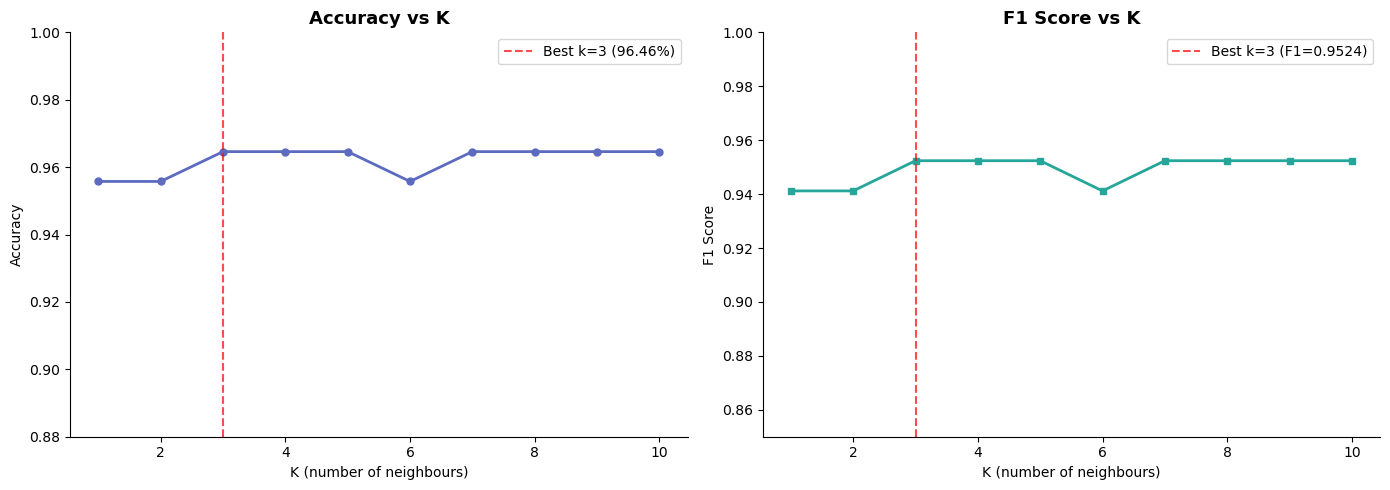


Best K by Accuracy : k = 3  →  96.46%
Best K by F1 Score : k = 3  →  0.9524


In [28]:
best_k_acc = k_values[np.argmax(accuracies)]
best_k_f1  = k_values[np.argmax(f1_scores)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(k_values, accuracies, marker='o', color='#5C6BC0', linewidth=2, markersize=5)
axes[0].axvline(x=best_k_acc, color='red', linestyle='--', alpha=0.7,
                label=f'Best k={best_k_acc} ({max(accuracies)*100:.2f}%)')
axes[0].set_title('Accuracy vs K', fontsize=13, fontweight='bold')
axes[0].set_xlabel('K (number of neighbours)')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].set_ylim(0.88, 1.0)

# F1 Score plot
axes[1].plot(k_values, f1_scores, marker='s', color='#26A69A', linewidth=2, markersize=5)
axes[1].axvline(x=best_k_f1, color='red', linestyle='--', alpha=0.7,
                label=f'Best k={best_k_f1} (F1={max(f1_scores):.4f})')
axes[1].set_title('F1 Score vs K', fontsize=13, fontweight='bold')
axes[1].set_xlabel('K (number of neighbours)')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].set_ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

print(f"\nBest K by Accuracy : k = {best_k_acc}  →  {max(accuracies)*100:.2f}%")
print(f"Best K by F1 Score : k = {best_k_f1}  →  {max(f1_scores):.4f}")

  Final KNN Results  (k = 3)
  Accuracy  : 0.9646  (96.46%)
  Precision : 0.9524
  Recall    : 0.9524
  F1 Score  : 0.9524


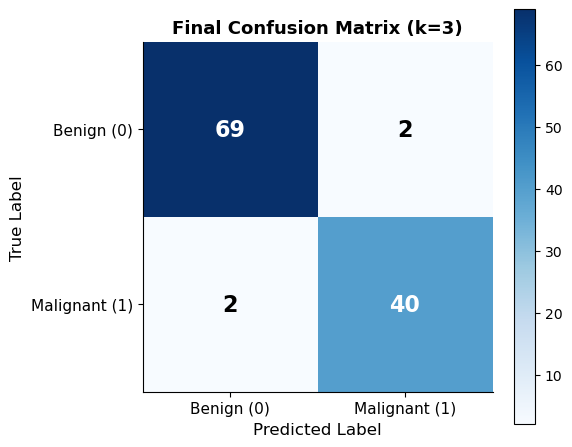

In [29]:
# Use the best k found above
final_k    = best_k_f1
y_pred_final = knn_predict(X_train, y_train, X_test, k=final_k)
final_metrics = compute_metrics(y_test, y_pred_final)

print("=" * 45)
print(f"  Final KNN Results  (k = {final_k})")
print("=" * 45)
print(f"  Accuracy  : {final_metrics['Accuracy']:.4f}  ({final_metrics['Accuracy']*100:.2f}%)")
print(f"  Precision : {final_metrics['Precision']:.4f}")
print(f"  Recall    : {final_metrics['Recall']:.4f}")
print(f"  F1 Score  : {final_metrics['F1 Score']:.4f}")
print("=" * 45)

plot_confusion_matrix(final_metrics, title=f'Final Confusion Matrix (k={final_k})')

Grid has 3,025 points to classify... this may take a moment.


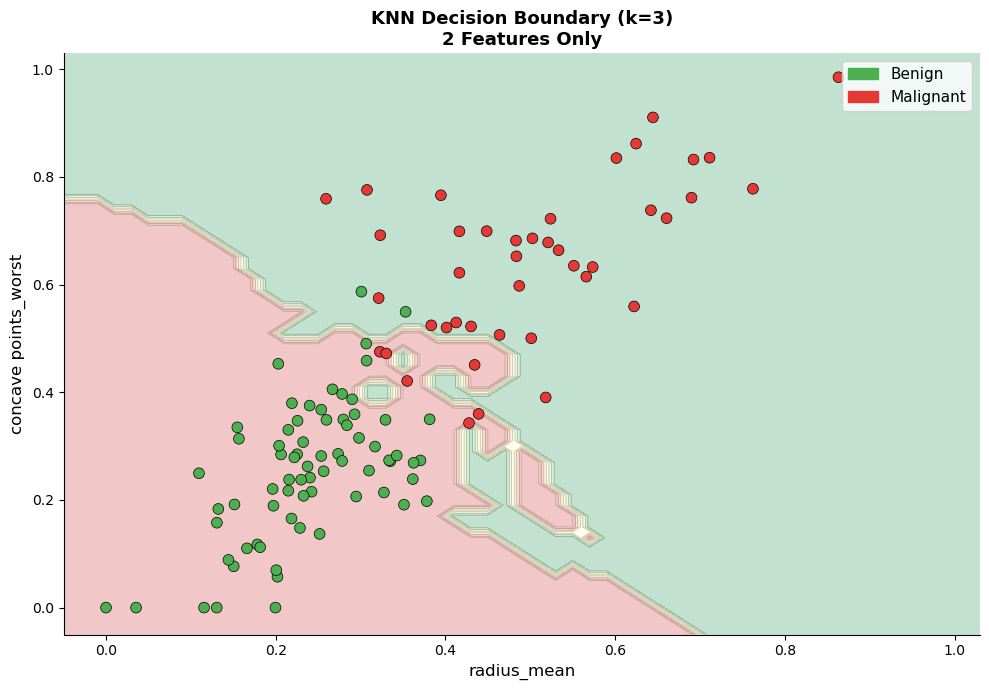

In [30]:
# Use radius_mean (col 0) and concave points_worst (col 27) — strong discriminators
feature_cols  = [0, 27]
feature_names = ['radius_mean', 'concave points_worst']

X2 = X_scaled[:, feature_cols]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2)

# Build a mesh grid over the 2D space
step   = 0.02
x_min, x_max = X2[:, 0].min() - 0.05, X2[:, 0].max() + 0.05
y_min, y_max = X2[:, 1].min() - 0.05, X2[:, 1].max() + 0.05
xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                     np.arange(y_min, y_max, step))

grid_points = np.c_[xx.ravel(), yy.ravel()]
print(f"Grid has {len(grid_points):,} points to classify... this may take a moment.")

Z = knn_predict(X2_train, y2_train, grid_points, k=final_k)
Z = Z.reshape(xx.shape)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdYlGn')
ax.contour(xx, yy, Z, colors='grey', linewidths=0.5, alpha=0.5)

# Scatter the actual test points
scatter_colors = np.where(y2_test == 1, '#E53935', '#4CAF50')
ax.scatter(X2_test[:, 0], X2_test[:, 1], c=scatter_colors,
           edgecolors='black', linewidths=0.5, s=60, zorder=3)

ax.set_xlabel(feature_names[0], fontsize=12)
ax.set_ylabel(feature_names[1], fontsize=12)
ax.set_title(f'KNN Decision Boundary (k={final_k})\n2 Features Only', fontsize=13, fontweight='bold')

benign_patch    = mpatches.Patch(color='#4CAF50', label='Benign')
malignant_patch = mpatches.Patch(color='#E53935', label='Malignant')
ax.legend(handles=[benign_patch, malignant_patch], fontsize=11)

plt.tight_layout()
plt.show()